# 🚗 Exploratory Data Analysis (EDA) — Cambodia Car Market
> **Project**: Cambodia Car Price Prediction  
> **Dataset**: Khmer24 Scraped Listings (`data/raw/` & `data/processed/`)  
> **Phase**: Phase 2 — Exploratory Data Analysis & Quality Profiling

---
## 🎯 Objectives:
1. **Understand distributions**: Target variable (`price`), features (`car_year`, `province`, `vehicle_brand`, `condition`, `tax_type`).
2. **Detect anomalies & outliers**: Unrealistic prices ($1 or $1,000,000+), impossible years, duplicated IDs.
3. **Analyze relationships**: Depreciation rate (`price` vs `car_year`), luxury brand valuation, Phnom Penh vs Provinces.
4. **Inspect missing values**: Identify feature sparsity (e.g., `mileage_km`, `transmission`, `engine_cc`).


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. 📥 Data Loading & Initial Overview
Let's inspect both the **raw scraped dataset** (`data/raw/khmer24_cars.parquet`) and the **cleaned dataset** (`data/processed/cars_clean.parquet`).


In [3]:
raw_path = "../data/raw/khmer24_cars.parquet"
clean_path = "../data/processed/cars_clean.parquet"

df_raw = pd.read_parquet(raw_path)
df_clean = pd.read_parquet(clean_path)

print(f"📦 Raw dataset shape      : {df_raw.shape[0]:,} rows | {df_raw.shape[1]} columns")
print(f"✨ Cleaned dataset shape  : {df_clean.shape[0]:,} rows | {df_clean.shape[1]} columns")


📦 Raw dataset shape      : 302 rows | 34 columns
✨ Cleaned dataset shape  : 650 rows | 34 columns


In [4]:
df_raw.columns

Index(['listing_id', 'listing_title', 'price', 'currency', 'discount_price',
       'is_premium', 'category', 'category_slug', 'province', 'province_slug',
       'district', 'location_full', 'seller_id', 'seller_name', 'seller_type',
       'seller_username', 'seller_phones', 'view_count', 'posted_at',
       'renewed_at', 'thumbnail_url', 'listing_url', 'vehicle_model_year',
       'vehicle_condition', 'vehicle_tax_type', 'vehicle_brand',
       'vehicle_model', 'vehicle_mileage_km', 'vehicle_fuel_type',
       'vehicle_transmission', 'vehicle_engine_cc', 'vehicle_color',
       'raw_specs', 'scraped_at'],
      dtype='str')

In [5]:
df_clean.columns

Index(['listing_id', 'listing_title', 'price', 'currency', 'discount_price',
       'is_premium', 'category', 'category_slug', 'province', 'province_slug',
       'district', 'location_full', 'seller_id', 'seller_name', 'seller_type',
       'seller_username', 'seller_phones', 'view_count', 'posted_at',
       'renewed_at', 'thumbnail_url', 'listing_url', 'vehicle_model_year',
       'vehicle_condition', 'vehicle_tax_type', 'vehicle_brand',
       'vehicle_model', 'vehicle_mileage_km', 'vehicle_fuel_type',
       'vehicle_transmission', 'vehicle_engine_cc', 'vehicle_color',
       'raw_specs', 'scraped_at'],
      dtype='str')

In [6]:
# Display sample records from cleaned dataset
df_clean.head(5)

,listing_id,listing_title,price,currency,discount_price,is_premium,category,category_slug,province,province_slug,...,vehicle_tax_type,vehicle_brand,vehicle_model,vehicle_mileage_km,vehicle_fuel_type,vehicle_transmission,vehicle_engine_cc,vehicle_color,raw_specs,scraped_at
0,13878476,Kia Carnival 2025 full Options(សាំង ប្រើបាន230...,44800.0,USD,None,None,Cars for Sale,cars-for-sale,Phnom Penh,phnom-penh,...,Plate Number,Kia,Carnival,None,Unknown,Unknown,None,None,"{""car-year"": 2025, ""tax-type"": ""Plate Number""}",2026-08-17T04:18:35.723489+00:00
1,13877751,ឡាន Jeep Wrangler Option Sahara 021 4xe លក់ ( ...,54000.0,USD,None,None,Cars for Sale,cars-for-sale,Phnom Penh,phnom-penh,...,Tax Paper,Jeep,Wrangler,None,Unknown,Unknown,None,None,"{""car-year"": 2021, ""tax-type"": ""Tax Paper""}",2026-08-17T04:18:35.724574+00:00
2,13859904,Prius 2007,9500.0,USD,None,None,Cars for Sale,cars-for-sale,Phnom Penh,phnom-penh,...,Plate Number,Toyota,Prius,None,Unknown,Unknown,None,None,"{""car-year"": 2007, ""tax-type"": ""Plate Number""}",2026-08-17T04:18:35.730586+00:00
3,13806166,Prius 2013 Option 2 សាងបាន,15900.0,USD,None,None,Cars for Sale,cars-for-sale,Phnom Penh,phnom-penh,...,Tax Paper,Toyota,Prius,None,Unknown,Unknown,None,None,"{""car-year"": 2013, ""tax-type"": ""Tax Paper""}",2026-08-17T04:18:35.730586+00:00
4,13863614,លក់ព្រោះអត់មានពេលជិះ,27000.0,USD,None,None,Cars for Sale,cars-for-sale,Siem Reap,siem-reap,...,Plate Number,Unknown,NaN,None,Unknown,Unknown,None,None,"{""car-year"": 2015, ""tax-type"": ""Plate Number""}",2026-08-17T04:18:35.733839+00:00


## 2. 🔍 Data Quality & Missing Value Profiling
Let's analyze feature sparsity and missing values to see what fields are available directly in the feed versus those requiring detail page scraping.


In [7]:
missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': pct,
    'Data Type': df_raw.dtypes
}).sort_values('Missing Count', ascending=False)

missing_df[missing_df['Missing Count'] > 0]


,Missing Count,Missing Percentage (%),Data Type
discount_price,302,100.0,object
is_premium,302,100.0,object
vehicle_color,302,100.0,object
vehicle_fuel_type,302,100.0,object
vehicle_transmission,302,100.0,object
vehicle_mileage_km,302,100.0,object
vehicle_engine_cc,302,100.0,object
vehicle_model,114,37.7,str
vehicle_brand,113,37.4,str
thumbnail_url,3,1.0,str


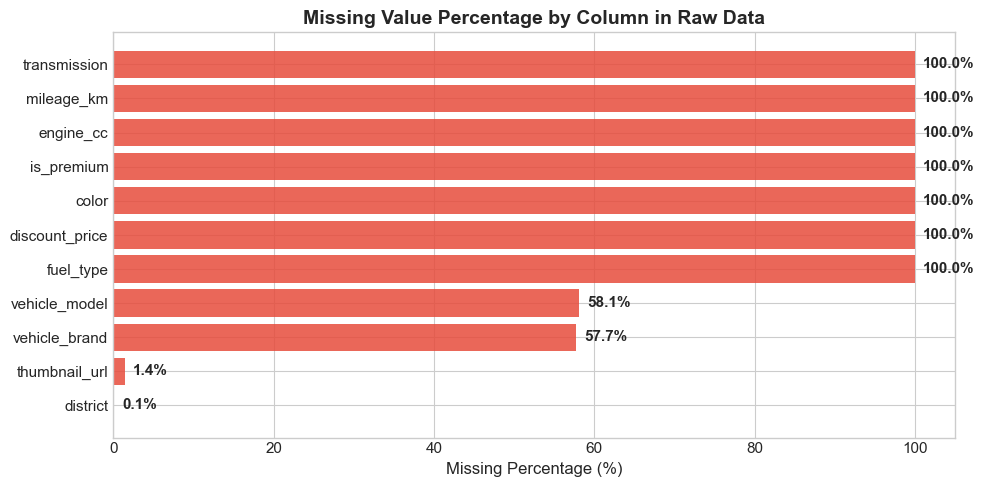

In [5]:
plt.figure(figsize=(10, 5))
missing_plot_data = missing_df[missing_df['Missing Percentage (%)'] > 0]['Missing Percentage (%)'].sort_values()
bars = plt.barh(missing_plot_data.index, missing_plot_data.values, color='#e74c3c', alpha=0.85)
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Value Percentage by Column in Raw Data')
plt.xlim(0, 105)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. 💰 Target Variable Analysis: Car Price (USD)
Understanding the distribution of `price` and why predicting `log(price)` is necessary for ML regression models.


In [6]:
# Summary statistics for price
price_stats = df_clean['price'].describe()
print("Price Statistics (USD):")
print(f"  Count  : {int(price_stats['count']):,}")
print(f"  Mean   : ${price_stats['mean']:,.2f}")
print(f"  Median : ${price_stats['50%']:,.2f}")
print(f"  Std Dev: ${price_stats['std']:,.2f}")
print(f"  Min    : ${price_stats['min']:,.2f}")
print(f"  Max    : ${price_stats['max']:,.2f}")
print(f"  Skew   : {df_clean['price'].skew():.2f} (High right skew)")


Price Statistics (USD):
  Count  : 942
  Mean   : $33,704.59
  Median : $23,100.00
  Std Dev: $37,096.76
  Min    : $1,200.00
  Max    : $298,000.00
  Skew   : 3.59 (High right skew)


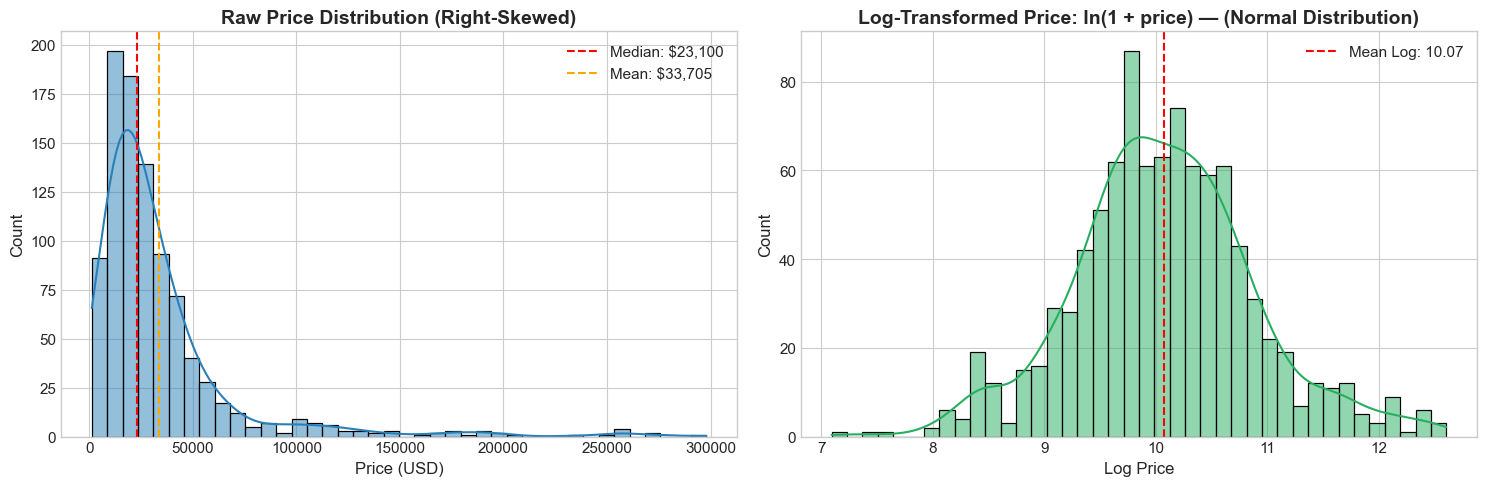

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Raw Price Distribution
sns.histplot(df_clean['price'], bins=40, kde=True, ax=ax1, color='#2980b9')
ax1.axvline(df_clean['price'].median(), color='red', linestyle='--', label=f"Median: ${df_clean['price'].median():,.0f}")
ax1.axvline(df_clean['price'].mean(), color='orange', linestyle='--', label=f"Mean: ${df_clean['price'].mean():,.0f}")
ax1.set_title('Raw Price Distribution (Right-Skewed)')
ax1.set_xlabel('Price (USD)')
ax1.legend()

# 2. Log-Transformed Price
log_price = np.log1p(df_clean['price'])
sns.histplot(log_price, bins=40, kde=True, ax=ax2, color='#27ae60')
ax2.axvline(log_price.mean(), color='red', linestyle='--', label=f"Mean Log: {log_price.mean():.2f}")
ax2.set_title('Log-Transformed Price: ln(1 + price) — (Normal Distribution)')
ax2.set_xlabel('Log Price')
ax2.legend()

plt.tight_layout()
plt.show()


## 4. 📅 Car Age & Depreciation Analysis
How does manufacturing year affect the market price in Cambodia?


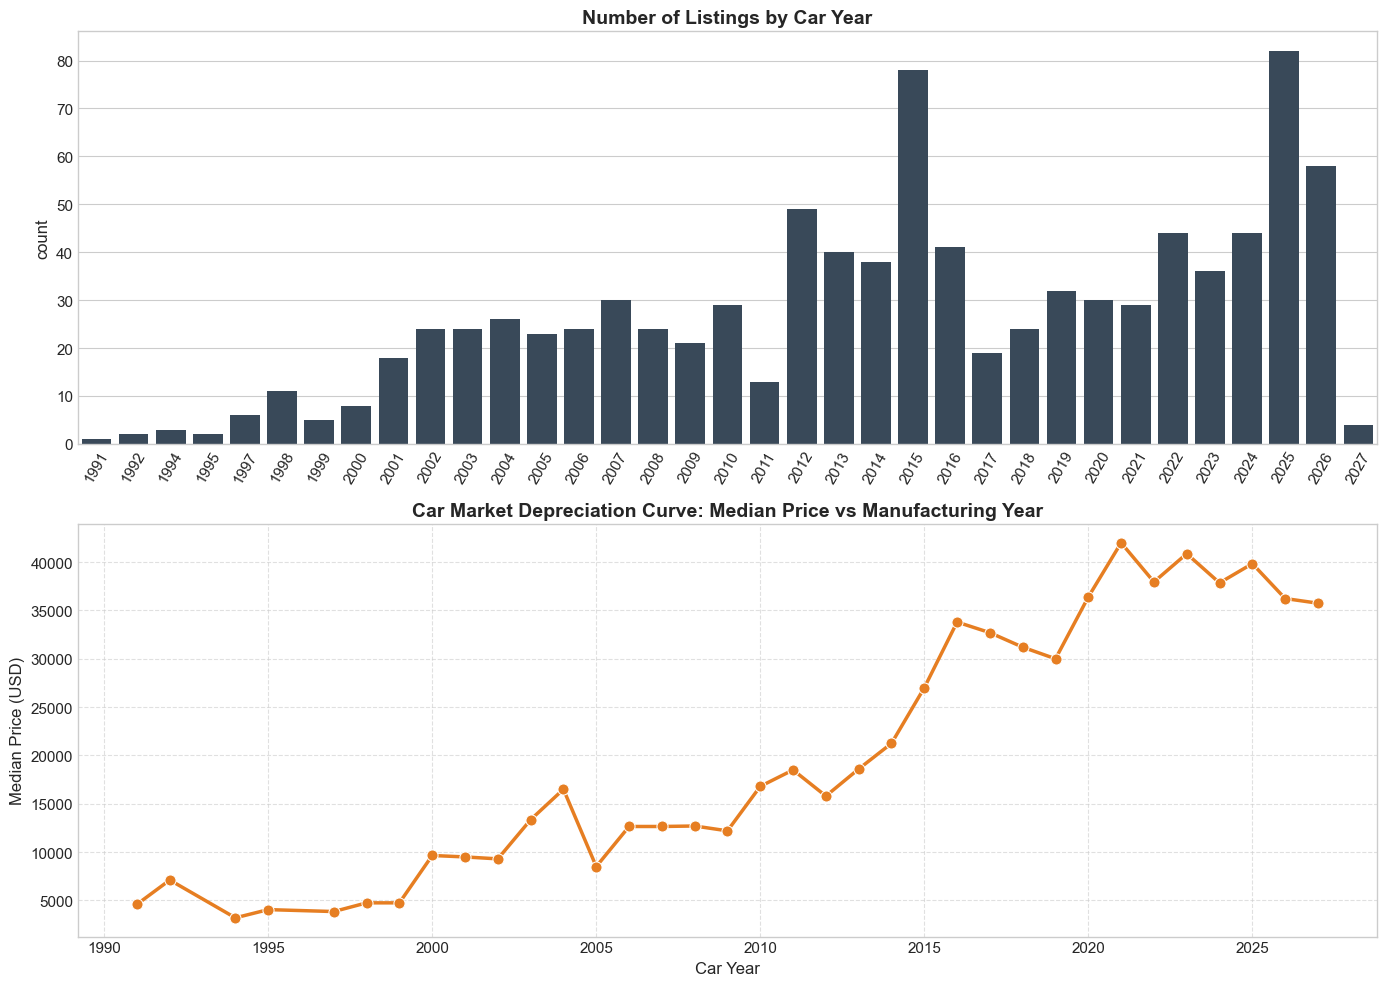

In [8]:
# Car Year Distribution and Median Price
year_summary = df_clean.groupby('car_year')['price'].agg(['count', 'median', 'mean']).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Listings count per year
sns.barplot(data=year_summary, x='car_year', y='count', ax=ax1, color='#34495e')
ax1.set_title('Number of Listings by Car Year')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=60)

# Median Price Trend (Depreciation Curve)
sns.lineplot(data=year_summary, x='car_year', y='median', ax=ax2, marker='o', color='#e67e22', linewidth=2.5, markersize=8)
ax2.set_title('Car Market Depreciation Curve: Median Price vs Manufacturing Year')
ax2.set_xlabel('Car Year')
ax2.set_ylabel('Median Price (USD)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 5. 🏷️ Brand & Market Segmentation
Which car brands are most dominant in Cambodia, and what is their price hierarchy?


C:\Users\mengh\AppData\Local\Temp\ipykernel_5908\1579100546.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_brands, x='price', y='vehicle_brand', order=brand_order, ax=ax2, palette='Blues_r')


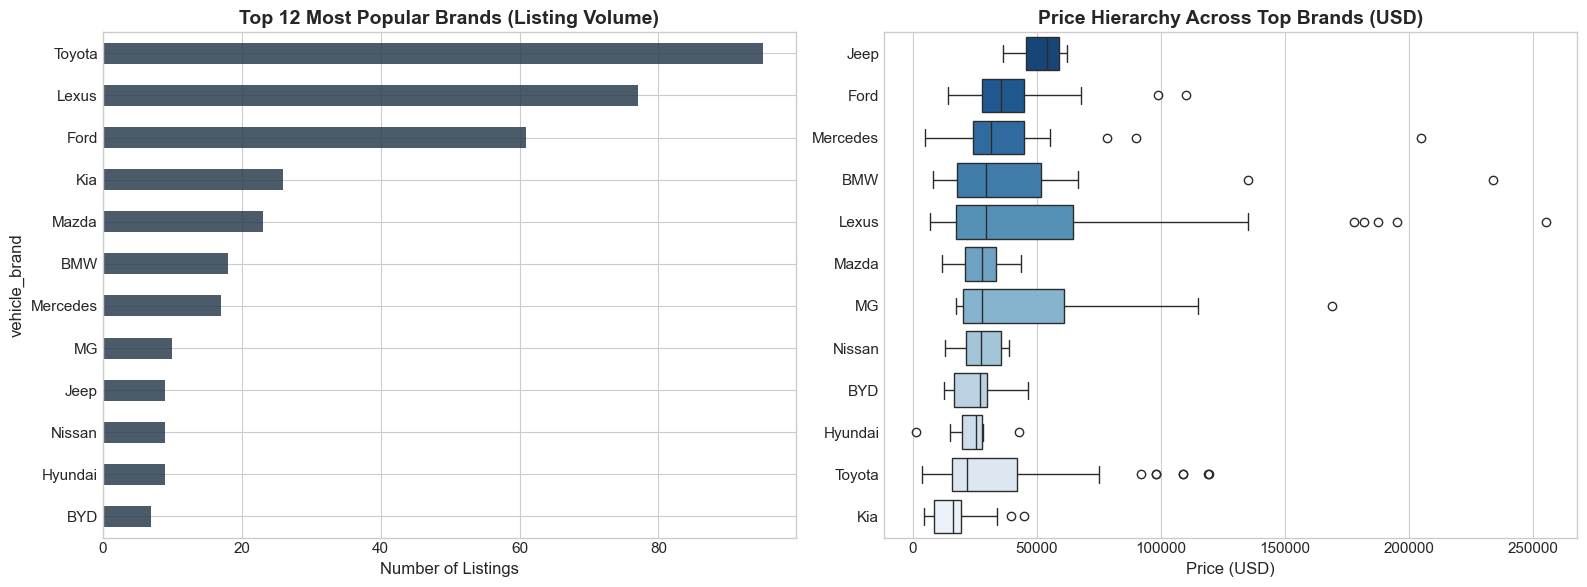

In [9]:
# Filter top brands with sufficient listing count
top_brands = df_clean['vehicle_brand'].value_counts()
top_brands = top_brands[top_brands.index != 'Unknown'].head(12)

df_top_brands = df_clean[df_clean['vehicle_brand'].isin(top_brands.index)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Market Share of Top Brands
top_brands.plot(kind='barh', ax=ax1, color='#2c3e50', alpha=0.85)
ax1.set_title('Top 12 Most Popular Brands (Listing Volume)')
ax1.set_xlabel('Number of Listings')
ax1.invert_yaxis()

# 2. Price Distribution by Brand (Boxplot)
brand_order = df_top_brands.groupby('vehicle_brand')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top_brands, x='price', y='vehicle_brand', order=brand_order, ax=ax2, palette='Blues_r')
ax2.set_title('Price Hierarchy Across Top Brands (USD)')
ax2.set_xlabel('Price (USD)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()


## 6. 🏛️ Impact of Tax Type, Condition, Location & Seller Type


C:\Users\mengh\AppData\Local\Temp\ipykernel_5908\2510216786.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='tax_type', y='price', order=tax_order, ax=axes[0, 0], palette='Set2')
C:\Users\mengh\AppData\Local\Temp\ipykernel_5908\2510216786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='car_condition', y='price', ax=axes[0, 1], palette='Pastel1')
C:\Users\mengh\AppData\Local\Temp\ipykernel_5908\2510216786.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_prov, x='province', y='price', ax=

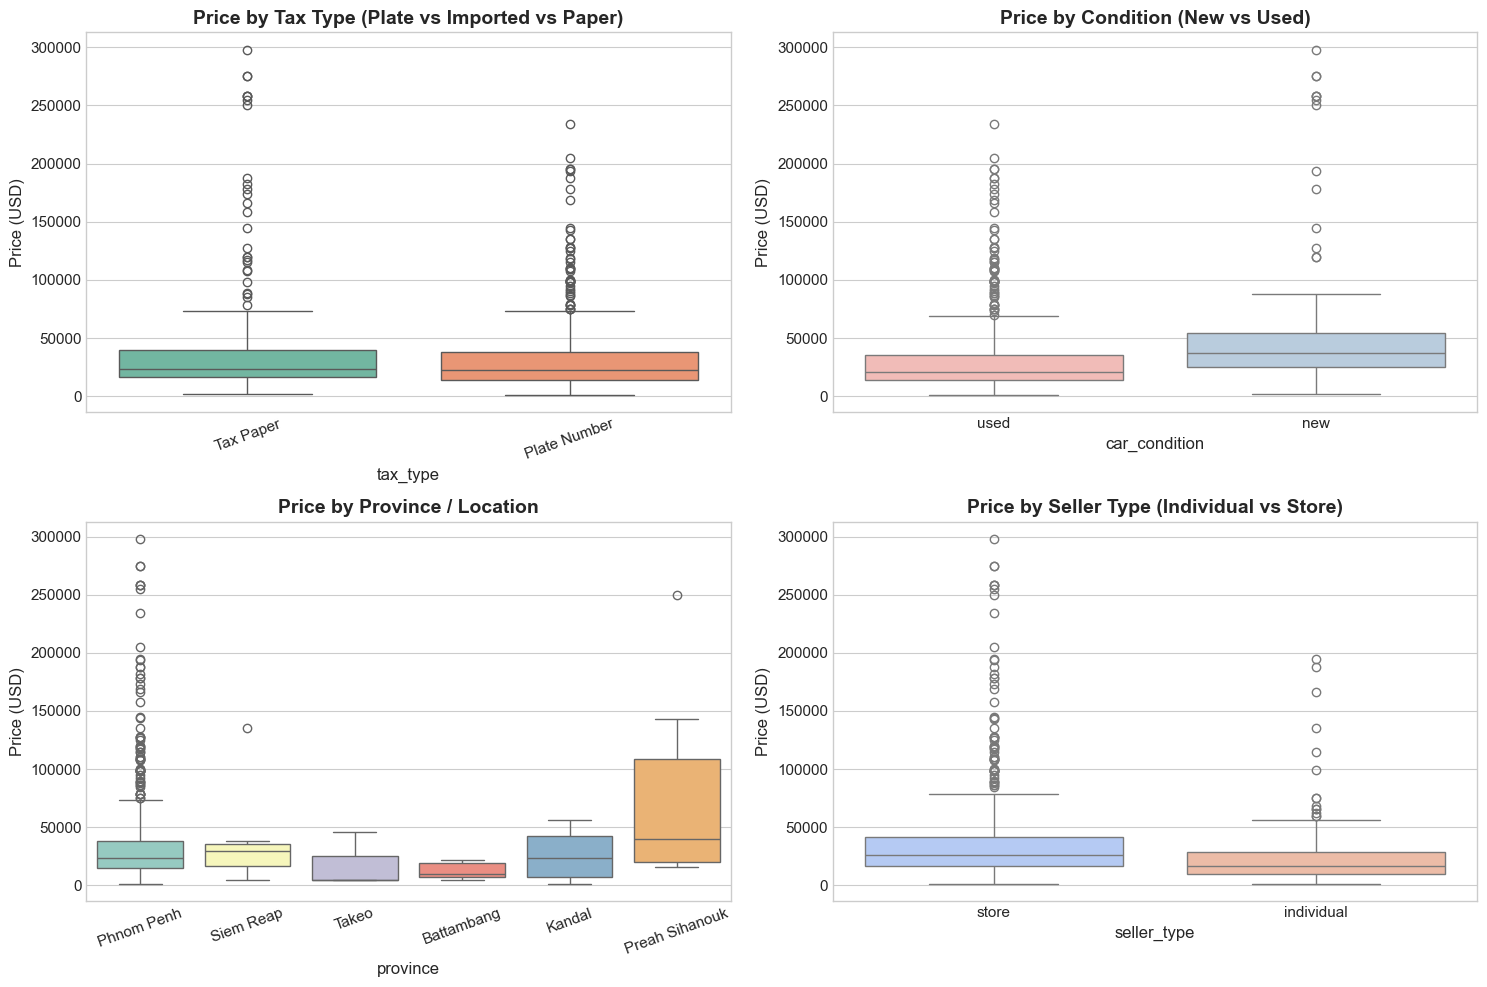

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tax Type vs Price
tax_order = df_clean.groupby('tax_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='tax_type', y='price', order=tax_order, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Price by Tax Type (Plate vs Imported vs Paper)')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].set_ylabel('Price (USD)')

# 2. Condition vs Price
sns.boxplot(data=df_clean, x='car_condition', y='price', ax=axes[0, 1], palette='Pastel1')
axes[0, 1].set_title('Price by Condition (New vs Used)')
axes[0, 1].set_ylabel('Price (USD)')

# 3. Top Provinces by Volume
top_provinces = df_clean['province'].value_counts().head(6).index
df_prov = df_clean[df_clean['province'].isin(top_provinces)]
sns.boxplot(data=df_prov, x='province', y='price', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Price by Province / Location')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].set_ylabel('Price (USD)')

# 4. Seller Type
sns.boxplot(data=df_clean, x='seller_type', y='price', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Price by Seller Type (Individual vs Store)')
axes[1, 1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()


## 7. 🔗 Numerical Correlations


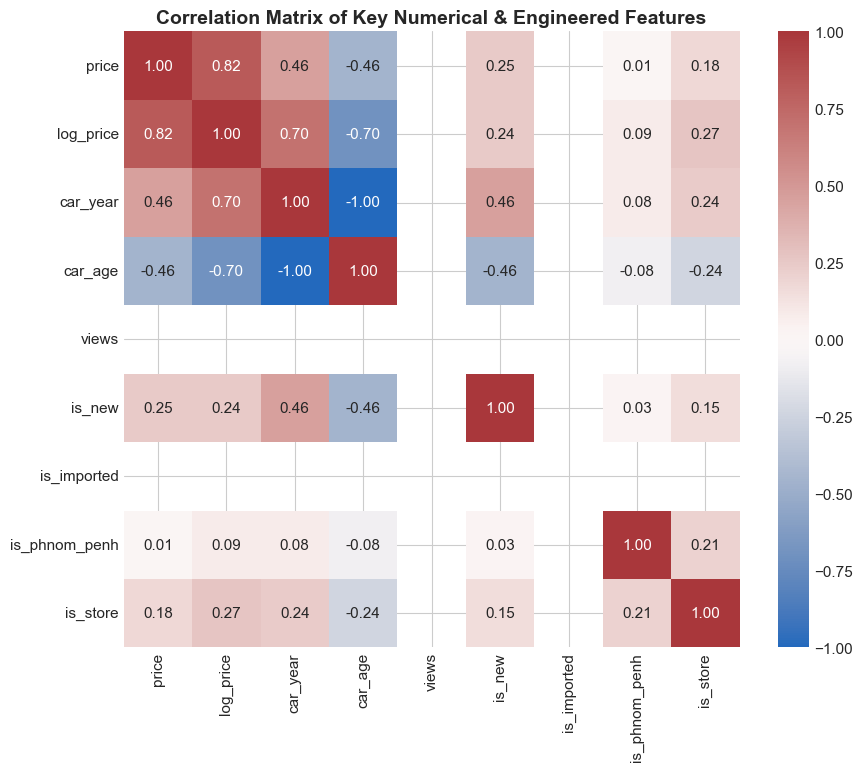

In [11]:
# Compute engineered numerical proxy features for correlation study
df_corr = df_clean.copy()
df_corr['car_age'] = 2026 - df_corr['car_year']
df_corr['log_price'] = np.log1p(df_corr['price'])
df_corr['is_new'] = (df_corr['car_condition'] == 'new').astype(int)
df_corr['is_imported'] = df_corr['tax_type'].str.lower().str.contains('import').astype(int)
df_corr['is_phnom_penh'] = (df_corr['province'] == 'Phnom Penh').astype(int)
df_corr['is_store'] = (df_corr['seller_type'] == 'store').astype(int)

cols_to_corr = ['price', 'log_price', 'car_year', 'car_age', 'views', 'is_new', 'is_imported', 'is_phnom_penh', 'is_store']
corr = df_corr[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Key Numerical & Engineered Features')
plt.show()


## 8. 💡 Key Takeaways & ML Pipeline Recommendations

### 📊 Summary Findings:
1. **Target Skewness**: Raw car price has extreme right skew (`skew > 3`). `log(price)` normalizes the target perfectly for regression algorithms.
2. **Strongest Predictors**:
   - `car_year` / `car_age` shows the strongest linear & non-linear relationship with price.
   - `vehicle_brand` introduces massive variance (e.g., Lexus/Mercedes vs Toyota vs Hyundai).
   - `tax_type` & `is_imported` creates distinct pricing tiers.
3. **Data Gaps**:
   - ~61% of raw titles need robust brand regex parsing (addressed in `parsers.py`).
   - `mileage_km`, `transmission`, and `fuel_type` are currently unpopulated from the feed and will add further predictive power once detail pages are scraped.
